In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_cohere import ChatCohere
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import operator

In [23]:
load_dotenv()

True

In [24]:
class EvaluationSchema(BaseModel):

    evaluation : Literal['approved', 'need_improvement'] = Field(..., description = 'Final Evaluation result'),
    feedback : str = Field(description = 'This the feedback for the tweet')

In [25]:
# create the model objects for different purpose.

generation_llm = ChatCohere(
    model = 'command-a-03-2025', 
    temperature = 0.7
)

evaluate_llm = ChatCohere(
    model = 'command-r7b-12-2024', 
    temperature = 0.7 
)
structured_evaluator_llm = evaluate_llm.with_structured_output(EvaluationSchema)

optimizer_llm = ChatCohere(
    model = 'command-a-reasoning-08-2025', 
    temperature = 0.7 
)

c:\Users\Mohd Uzaif\Desktop\DS\Agentic AI\.myenv\Lib\site-packages\pydantic\json_schema.py:2463: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Final Evaluation result'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [26]:
# define the state of the graph.
class TweetState(TypedDict):
    topic : str 
    tweet : str 
    evaluation : Literal['approved', 'need_improvement']
    feedback : str 
    iteration : int 
    max_iteration : int 

    tweet_history : Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

### Define the nodes of the graph.

In [27]:
# define the generate tweet node.
def generate_tweet(state : TweetState): 

    # fetch the topic from the state.
    topic = state['topic']

    # build a prompt.
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
                    Write a short, original, and hilarious tweet on the topic: "{topic}".

                    Rules:
                    - Do NOT use question-answer format.
                    - Max 280 characters.
                    - Use observational humor, irony, sarcasm, or cultural references.
                    - Think in meme logic, punchlines, or relatable takes.
                    - Use simple, day to day english
                    """)
    ]

    # generate the tweet on the given topic. 
    response = generation_llm.invoke(messages).content

    # partially stored into a state.
    return {
        'tweet' : response,
        'tweet_history' : [response]
    }

In [28]:
def evaluate_tweet(state : TweetState):
    
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: "{state['tweet']}"

            Use the criteria below to evaluate the tweet:

            1. Originality – Is this fresh, or have you seen it a hundred times before?  
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
            3. Punchiness – Is it short, sharp, and scroll-stopping?  
            4. Virality Potential – Would people retweet or share it?  
            5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"  
            - feedback: One paragraph explaining the strengths and weaknesses 
            """)
            ]

    response = structured_evaluator_llm.invoke(messages)

    return {
        'evaluation' : response.evaluation, 
        'feedback' : response.feedback,
        'feedback_history' : [response.feedback]
    }

In [29]:
# check condition node for the conditional chain.
def route_evaluation(state : TweetState) -> Literal['approved', 'need_improvement']:

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'need_improvement'

In [30]:
# define the optimize node.
def optimize_tweet(state : TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {
        'tweet' : response, 
        'iteration' : iteration
    }
    

### Define the graph.

In [31]:
graph = StateGraph(TweetState)

# add the nodes in the graph.
graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

# add the edges in the graph.
graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved' : END, 'need_improvement' : 'optimize_tweet'})
graph.add_edge('optimize_tweet', END)


workflow = graph.compile()

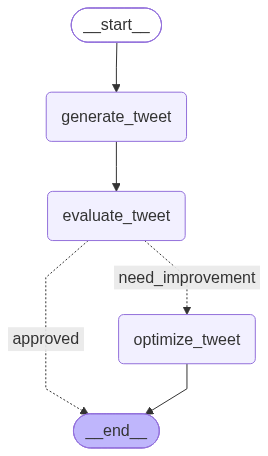

In [32]:
workflow

In [33]:
# define the initial state.
initial_state = {
    'topic' : 'football', 
    'iteration' : 1, 
    'max_iteration' : 5
}

result = workflow.invoke(initial_state)

result

{'topic': 'football',
 'tweet': 'Me: I’m just here for the halftime show and snacks.  \nAlso me, 3 hours later: *screaming at the ref like I understand offside.* #FootballLogic #SnacksAreTheRealMVP',
 'evaluation': 'approved',
 'feedback': "This tweet is a clever play on the idea of enjoying a football match for the entertainment value rather than the sport itself. It effectively captures the dual nature of the viewer's experience, where the initial intention is lighthearted, but the prolonged engagement turns into an intense, passionate involvement. The humor lies in the contrast between the casual 'just here for the halftime show and snacks' and the later 'screaming at the ref' behavior. The use of hashtags like #FootballLogic and #SnacksAreTheRealMVP adds a layer of humor and context, making it relatable to football enthusiasts. The tweet is short, sharp, and scroll-stopping, with a strong punchline that captures the essence of the experience. It has a high potential for virality du